In [6]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF
from gpzoo.gp import GaussianPrior, SVGP, VNNGP, MGGP_WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, plot_factors, rescale_spatial_coords, add_jitter, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans

import matplotlib.patheffects as path_effects
import pandas as pd

In [2]:
adata = sq.datasets.slideseqv2()
adata = adata.raw.to_adata()

<Axes: >

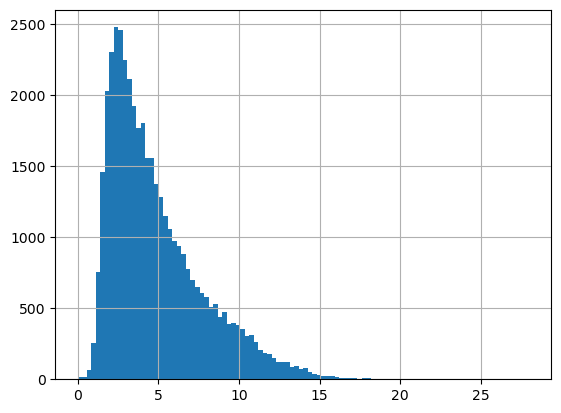

In [3]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.pct_counts_mt.hist(bins=100)


In [4]:
adata = adata[adata.obs.pct_counts_mt < 20] #from 53K to 45K
sc.pp.filter_cells(adata, min_counts=100)
sc.pp.filter_genes(adata, min_cells=10)

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [11]:
df = pd.read_csv('notebooks/data/slideseq_labels.csv', skiprows=4)

In [12]:
adata.obs['class_name'] = df['class_name'].values

/tmp/ipykernel_3790883/580149730.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(adata.obs['class_name'].values.categories))


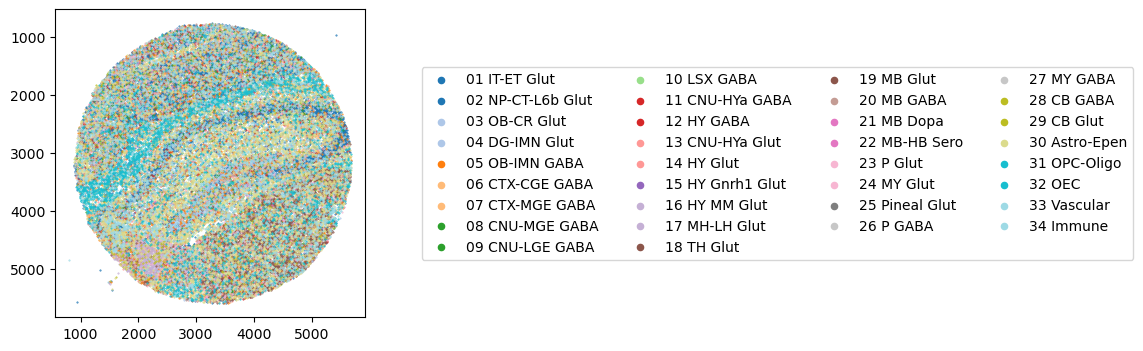

In [95]:
X = adata.obsm['spatial']
colors = plt.cm.get_cmap('tab20', len(adata.obs['class_name'].values.categories))

size=4
fig, ax = plt.subplots(1, 1, figsize=(size, size), tight_layout=True)


for i, category in enumerate(adata.obs['class_name'].values.categories):
    mask = adata.obs['class_name']==category
    ax.scatter(X[mask,0], X[mask, 1], s=0.2, label=category, color=colors.colors[i])

ax.invert_yaxis()

plt.legend(bbox_to_anchor=(3.5, 0.5), loc='right', ncol=4, markerscale=10)


In [100]:
groupsX = torch.tensor(adata.obs['class_name'].values.codes).type(torch.LongTensor)

Text(0, 0.5, 'number of cells')

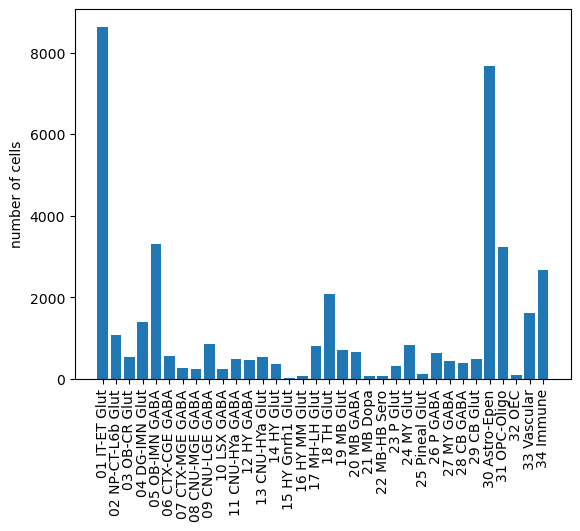

In [126]:
plt.bar(*torch.unique(groupsX, return_counts=True));
plt.xticks(np.unique(adata.obs['class_name'].values.codes), labels =adata.obs['class_name'].values.categories.values);
plt.xticks(rotation=90);
plt.ylabel('number of cells')